# GW150914 GWFish Fisher matrices: space, LVK, and CE networks

This notebook uses **GWFish** for the detector response, `IMRPhenomXPHM`
waveform, numerical derivatives, Fisher matrices, and SVD inversion.

The estimated parameters are
\[
(\mathcal{M}_c, q, d_L, \iota, \alpha, \delta, \psi,
t_c, \phi_c, a_1, a_2).
\]

Networks shown in the corner plots:

- **LISA**
- **LGWA**
- **LVK**: LIGO Hanford, LIGO Livingston, Virgo, and KAGRA at the built-in
  GWFish O5 sensitivities
- **Combined**: LISA + LGWA + LVK

The observation reference epoch is fixed below and the coalescence time is
set to exactly **four Julian years after that epoch**. The quoted chirp mass
is detector-frame, consistent with the GWFish `chirp_mass` parameter.

A separate 2CE Fisher result is still computed and saved, but LVK replaces 2CE
in the intrinsic and extrinsic corner plots.


In [1]:
import os
import sys
import types
import importlib.machinery
import importlib.util
from pathlib import Path

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'code' else cwd
OUTDIR = PROJECT_ROOT / 'plots' / 'gw150914_gwfish_fisher'
DATADIR = PROJECT_ROOT / 'data' / 'gw150914_gwfish_fisher'
OUTDIR.mkdir(parents=True, exist_ok=True)
DATADIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / '.matplotlib-cache'))
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

# This Python build may lack the optional _lzma extension. Astropy only
# probes for it during import here; the notebook does not read .xz files.
try:
    import lzma  # noqa: F401
except ModuleNotFoundError:
    lzma_stub = types.ModuleType('lzma')
    lzma_stub.__spec__ = importlib.machinery.ModuleSpec('lzma', loader=None)
    class LZMAFile:
        pass
    lzma_stub.LZMAFile = LZMAFile
    lzma_stub.open = lambda *args, **kwargs: None
    sys.modules['lzma'] = lzma_stub

import corner
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib
matplotlib.rcParams['text.usetex'] = True

%config InlineBackend.figure_format = 'retina'
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

# GWFish currently calls np.trapz, removed in NumPy 2.0.
if not hasattr(np, 'trapz'):
    np.trapz = np.trapezoid

import GWFish
from GWFish.modules import detection, ephemeris, fishermatrix, waveforms

tnf_path = PROJECT_ROOT / 'code' / 'test_notebook_functions.py'
tnf_spec = importlib.util.spec_from_file_location('test_notebook_functions', tnf_path)
tnf = importlib.util.module_from_spec(tnf_spec)
tnf_spec.loader.exec_module(tnf)

plt.rcParams.update({
    'figure.figsize': (8.0, 5.5),
    'font.size': 20,
    'axes.grid': True,
    'grid.linestyle': ':',
})

/home/ansonchen/multiband_cosmo/.venv/lib/python3.12/site-packages/lalsimulation/_lalsimulation_swig.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


## Source and timing assumptions

`OBSERVATION_START_GPS` is the reference epoch. The coalescence time passed
to GWFish is `OBSERVATION_START_GPS + 4 years`, so the source is exactly
four years from merger at the observation start.

In [2]:
YEAR = 365.25 * 24 * 3600
TIME_TO_MERGER_YR = 4.0
OBSERVATION_START_GPS = 1735257618.0
COALESCENCE_GPS = OBSERVATION_START_GPS + TIME_TO_MERGER_YR * YEAR

GW150914 = {
    'chirp_mass': 28.1,
    'mass_ratio': 29.0 / 36.0,
    'luminosity_distance': 200.0,
    'redshift': 0.04,
    'theta_jn': 0.8,
    'ra': 3.0,
    'dec': 0.0,
    'psi': 0.4,
    'geocent_time': COALESCENCE_GPS,
    'phase': 1.5,
    'a_1': 0.10,
    'a_2': 0.05,
}

FISHER_PARAMETERS = [
    'chirp_mass',
    'mass_ratio',
    'luminosity_distance',
    'theta_jn',
    'ra',
    'dec',
    'psi',
    'geocent_time',
    'phase',
    'a_1',
    'a_2',
]

INTRINSIC_PARAMETERS = [
    'chirp_mass',
    'mass_ratio',
    'geocent_time',
    'phase',
    'a_1',
    'a_2',
]
EXTRINSIC_PARAMETERS = [
    'luminosity_distance',
    'theta_jn',
    'ra',
    'dec',
    'psi',
]

PARAMETER_LABELS = {
    'chirp_mass': r'$(\mathcal{M}_c-28.1)\,/\,10^{-4}\,M_\odot$',
    'mass_ratio': r'$q$',
    'luminosity_distance': r'$d_L\,[\mathrm{Mpc}]$',
    'theta_jn': r'$\iota\,[\mathrm{rad}]$',
    'ra': r'$\alpha\,[\mathrm{rad}]$',
    'dec': r'$\delta\,[\mathrm{rad}]$',
    'psi': r'$\psi\,[\mathrm{rad}]$',
    'geocent_time': r'$t_c-t_{c,0}\,[\mathrm{s}]$',
    'phase': r'$\phi_c\,[\mathrm{rad}]$',
    'a_1': r'$a_1$',
    'a_2': r'$a_2$',
}

print(f'Time to merger: {(GW150914["geocent_time"] - OBSERVATION_START_GPS) / YEAR:.6f} yr')
print(f'Observation-start GPS: {OBSERVATION_START_GPS:.1f}')
print(f'Coalescence GPS:       {COALESCENCE_GPS:.1f}')

Time to merger: 4.000000 yr
Observation-start GPS: 1735257618.0
Coalescence GPS:       1861488018.0


## Detector configuration

GWFish includes LISA and LGWA configurations. For the two-CE network, this
notebook writes a small GWFish-compatible YAML file using the bundled CE2
PSD at two geographically distinct sites. Distinct sites are essential for
sky localization and polarization information.

In [3]:
GWFISH_ROOT = Path(GWFish.__file__).resolve().parent
PSD_DIR = GWFISH_ROOT / 'detector_psd'
TWO_CE_CONFIG = DATADIR / 'two_ce2_sites.yaml'

TWO_CE_CONFIG.write_text(f'''CE_LHO:
  lat: 46.46 * np.pi / 180.
  lon: -119.4 * np.pi / 180.
  opening_angle: np.pi / 2.
  azimuth: 126. * np.pi / 180.
  psd_path: "Path('{PSD_DIR}')"
  psd_data: CE2_psd.txt
  duty_factor: 1.0
  detector_class: earthL
  plotrange: 5, 2048, 1e-26, 1e-20
  fmin: 5
  fmax: 1024
  spacing: geometric
  npoints: 1800
  arm_length: 40000
CE_LLO:
  lat: 30.56 * np.pi / 180.
  lon: -90.77 * np.pi / 180.
  opening_angle: np.pi / 2.
  azimuth: 197.7 * np.pi / 180.
  psd_path: "Path('{PSD_DIR}')"
  psd_data: CE2_psd.txt
  duty_factor: 1.0
  detector_class: earthL
  plotrange: 5, 2048, 1e-26, 1e-20
  fmin: 5
  fmax: 1024
  spacing: geometric
  npoints: 1800
  arm_length: 40000
''')

NETWORKS = {
    'LISA': [('LISA', 'LISA', None)],
    'LGWA': [('LGWA', 'LGWA', None)],
    '2CE': [
        ('CE-LHO', 'CE_LHO', TWO_CE_CONFIG),
        ('CE-LLO', 'CE_LLO', TWO_CE_CONFIG),
    ],
    'LVK': [
        ('LIGO Hanford O5', 'LHO', None),
        ('LIGO Livingston O5', 'LLO', None),
        ('Virgo O5', 'VIR', None),
        ('KAGRA O5', 'KAG', None),
    ],
}
NETWORKS['Combined'] = NETWORKS['LISA'] + NETWORKS['LGWA'] + NETWORKS['LVK']
CORNER_NETWORKS = ['LISA', 'LGWA', 'LVK', 'Combined']

class BuiltinMoonEphemeris(ephemeris.MoonEphemeris):
    # Use Astropy's built-in Moon ephemeris without network downloads.
    def get_icrs_from_times(self, times):
        from astropy.coordinates import get_body_barycentric
        from astropy.time import Time
        return get_body_barycentric(
            'moon', Time(times, format='gps'), ephemeris='builtin'
        )

SPACE_PSD_FUNCTIONS = {
    'TAIJI_LISA_RESPONSE': lambda frequency: tnf.taiji_psd(
        frequency, include_confusion=True, observation_years=TIME_TO_MERGER_YR
    ),
    'TIANQIN_LISA_RESPONSE': lambda frequency: tnf.tianqin_psd(
        frequency, observation_years=TIME_TO_MERGER_YR
    ),
}


def lisa_response_detector_with_repo_psd(detector_name):
    """Clone the GWFish LISA response and replace only its component PSDs."""
    detector = detection.Detector('LISA')
    frequency = np.asarray(detector.frequencyvector, dtype=float).squeeze()
    psd = np.asarray(SPACE_PSD_FUNCTIONS[detector_name](frequency), dtype=float)
    valid = np.isfinite(psd) & (psd > 0.0)
    if not np.all(valid):
        raise ValueError(f'Invalid repository PSD values for {detector_name}')
    for component in detector.components:
        component.psd_data = np.column_stack([frequency, psd])
        component.Sn = interp1d(
            frequency,
            psd,
            bounds_error=False,
            fill_value=np.inf,
            assume_sorted=True,
        )
    detector.name = detector_name
    return detector


def make_detector(detector_name, config=None):
    if detector_name in SPACE_PSD_FUNCTIONS:
        return lisa_response_detector_with_repo_psd(detector_name)
    detector = detection.Detector(detector_name, config=config) if config else detection.Detector(detector_name)
    if detector.location == 'moon':
        for component in detector.components:
            component.ephem = BuiltinMoonEphemeris()
    return detector


## GWFish Fisher matrices

GWFish computes the detector projection and finite-difference derivatives.
Independent-detector Fisher matrices add directly. The covariance uses the
package's SVD inversion, which is important for weakly constrained
single-detector directions.

In [4]:
def sky_localization_area(covariance, declination, confidence=0.90):
    """Return the covariance-aware RA-Dec credible-region solid angle."""
    ra_index = FISHER_PARAMETERS.index('ra')
    dec_index = FISHER_PARAMETERS.index('dec')
    angular_covariance = covariance[np.ix_([ra_index, dec_index], [ra_index, dec_index])]
    determinant = max(float(np.linalg.det(angular_covariance)), 0.0)
    if not 0.0 < confidence < 1.0:
        raise ValueError('confidence must lie strictly between 0 and 1')
    chi_squared_contour = -2.0 * np.log1p(-confidence)
    area_sr = np.pi * chi_squared_contour * abs(np.cos(declination)) * np.sqrt(determinant)
    area_deg2 = area_sr * (180.0 / np.pi) ** 2
    return area_sr, area_deg2


def compute_network_fisher(detector_specs, parameters):
    size = len(FISHER_PARAMETERS)
    network_fisher = np.zeros((size, size))
    detector_rows = []

    for detector_label, detector_name, config in detector_specs:
        detector = make_detector(detector_name, config=config)
        detector_fisher, detector_snr_squared = fishermatrix.compute_detector_fisher(
            detector,
            parameters,
            fisher_parameters=FISHER_PARAMETERS,
            waveform_model='IMRPhenomXPHM',
            waveform_class=waveforms.LALFD_Waveform,
            use_duty_cycle=False,
        )
        network_fisher += detector_fisher
        detector_rows.append({
            'detector': detector_label,
            'snr': float(np.sqrt(detector_snr_squared)),
        })

    covariance, singular_values = fishermatrix.invertSVD(network_fisher)
    if covariance is None:
        raise RuntimeError('GWFish SVD inversion failed')
    covariance = 0.5 * (covariance + covariance.T)
    uncertainties = np.sqrt(np.clip(np.diag(covariance), 0.0, np.inf))
    sky_area_90_sr, sky_area_90_deg2 = sky_localization_area(
        covariance, parameters['dec'], confidence=0.90
    )

    return {
        'fisher': network_fisher,
        'covariance': covariance,
        'uncertainties': uncertainties,
        'singular_values': np.asarray(singular_values),
        'rank': int(np.linalg.matrix_rank(network_fisher)),
        'network_snr': float(np.sqrt(sum(row['snr'] ** 2 for row in detector_rows))),
        'detector_rows': detector_rows,
        'sky_localization_90_sr': sky_area_90_sr,
        'sky_localization_90_deg2': sky_area_90_deg2,
    }

fisher_results = {
    network_name: compute_network_fisher(detector_specs, GW150914)
    for network_name, detector_specs in NETWORKS.items()
}

for network_name, result in fisher_results.items():
    np.savetxt(DATADIR / f'fisher_{network_name.lower()}.txt', result['fisher'])
    np.savetxt(DATADIR / f'covariance_{network_name.lower()}.txt', result['covariance'])
    print(f'\n{network_name}: SNR={result["network_snr"]:.3f}, rank={result["rank"]}/{len(FISHER_PARAMETERS)}')
    for row in result['detector_rows']:
        print(f'  {row["detector"]}: SNR={row["snr"]:.3f}')
    for parameter, sigma in zip(FISHER_PARAMETERS, result['uncertainties']):
        print(f'  sigma({parameter}) = {sigma:.6g}')
    print(
        f"  90% sky localization = {result['sky_localization_90_deg2']:.6g} deg^2 "
        f"({result['sky_localization_90_sr']:.6g} sr)"
    )



LISA: SNR=5.592, rank=8/11
  LISA: SNR=5.592
  sigma(chirp_mass) = 0.000155538
  sigma(mass_ratio) = 0.38777
  sigma(luminosity_distance) = 174.036
  sigma(theta_jn) = 1.0122
  sigma(ra) = 0.175901
  sigma(dec) = 0.1767
  sigma(psi) = 1.41261
  sigma(geocent_time) = 19.1875
  sigma(phase) = 51.9319
  sigma(a_1) = 0.0196221
  sigma(a_2) = 0.025473
  90% sky localization = 1476.02 deg^2 (0.44962 sr)

LGWA: SNR=84.771, rank=10/11
  LGWA: SNR=84.771
  sigma(chirp_mass) = 1.75902e-05
  sigma(mass_ratio) = 0.0294105
  sigma(luminosity_distance) = 75.9689
  sigma(theta_jn) = 0.393932
  sigma(ra) = 0.00676702
  sigma(dec) = 0.0160808
  sigma(psi) = 0.807185
  sigma(geocent_time) = 1.11755
  sigma(phase) = 3.15102
  sigma(a_1) = 1.60914
  sigma(a_2) = 2.0893
  90% sky localization = 1.88395 deg^2 (0.000573884 sr)

2CE: SNR=6434.467, rank=11/11
  CE-LHO: SNR=4187.160
  CE-LLO: SNR=4885.699
  sigma(chirp_mass) = 0.000207897
  sigma(mass_ratio) = 0.000974711
  sigma(luminosity_distance) = 0.58694

In [5]:
summary_rows = []
for network_name, result in fisher_results.items():
    row = {
        'network': network_name,
        'network_snr': result['network_snr'],
        'rank': result['rank'],
        'sky_localization_90_sr': result['sky_localization_90_sr'],
        'sky_localization_90_deg2': result['sky_localization_90_deg2'],
    }
    row.update({
        f'sigma_{parameter}': sigma
        for parameter, sigma in zip(FISHER_PARAMETERS, result['uncertainties'])
    })
    summary_rows.append(row)

summary_path = DATADIR / 'gw150914_gwfish_fisher_summary.csv'
columns = list(summary_rows[0])
with summary_path.open('w') as handle:
    handle.write(','.join(columns) + '\n')
    for row in summary_rows:
        handle.write(','.join(str(row[column]) for column in columns) + '\n')
print(f'Saved {summary_path}')

Saved /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher/gw150914_gwfish_fisher_summary.csv


## Expanded combined networks with LISA-response Taiji/TianQin

Four additional calculations replace the single LISA entry in the original
combined network with:

1. **LISA + LGWA + 2CE**
2. **LISA + Taiji + LGWA + 2CE**
3. **LISA + Taiji + TianQin + LGWA + 2CE**
4. **LISA + Taiji + TianQin + LGWA + LVK**

Taiji and TianQin use the **same GWFish orbital response and frequency grid as
LISA**, while their PSDs are evaluated with `taiji_psd` and `tianqin_psd` from
`code/test_notebook_functions.py`.

This is intentionally a response-identical approximation: it changes the noise
curves but does not introduce independent Taiji/TianQin orbital geometries.
All results are printed and saved, but none is included in the corner plots.


In [6]:
EXPANDED_NETWORK_SPECS = {
    'LGWA + LVK': NETWORKS['LGWA'] + NETWORKS['LVK'],
    'LGWA + 2CE': NETWORKS['LGWA'] + NETWORKS['2CE'],
    'LISA + LGWA + 2CE': (
        NETWORKS['LISA'] + NETWORKS['LGWA'] + NETWORKS['2CE']
    ),
    'LISA-Taiji + LGWA + 2CE': [
        ('LISA', 'LISA', None),
        ('Taiji (LISA response)', 'TAIJI_LISA_RESPONSE', None),
    ] + NETWORKS['LGWA'] + NETWORKS['2CE'],
    'LISA-Taiji-TianQin + LGWA + 2CE': [
        ('LISA', 'LISA', None),
        ('Taiji (LISA response)', 'TAIJI_LISA_RESPONSE', None),
        ('TianQin (LISA response)', 'TIANQIN_LISA_RESPONSE', None),
    ] + NETWORKS['LGWA'] + NETWORKS['2CE'],
    'LISA-Taiji-TianQin + LGWA + LVK': [
        ('LISA', 'LISA', None),
        ('Taiji (LISA response)', 'TAIJI_LISA_RESPONSE', None),
        ('TianQin (LISA response)', 'TIANQIN_LISA_RESPONSE', None),
    ] + NETWORKS['LGWA'] + NETWORKS['LVK'],
}

EXPANDED_OUTPUT_NAMES = {
    'LGWA + LVK': 'combined_lgwa_lvk',
    'LGWA + 2CE': 'combined_lgwa_2ce',
    'LISA + LGWA + 2CE': 'combined_lisa_lgwa_2ce',
    'LISA-Taiji + LGWA + 2CE': 'combined_lisa_taiji_lgwa_2ce',
    'LISA-Taiji-TianQin + LGWA + 2CE': 'combined_lisa_taiji_tianqin_lgwa_2ce',
    'LISA-Taiji-TianQin + LGWA + LVK': 'combined_lisa_taiji_tianqin_lgwa_lvk',
}

expanded_combined_results = {}
for network_label, detector_specs in EXPANDED_NETWORK_SPECS.items():
    result = compute_network_fisher(detector_specs, GW150914)
    expanded_combined_results[network_label] = result
    output_name = EXPANDED_OUTPUT_NAMES[network_label]

    np.savetxt(DATADIR / f'fisher_{output_name}.txt', result['fisher'])
    np.savetxt(DATADIR / f'covariance_{output_name}.txt', result['covariance'])

    summary_path = DATADIR / f'{output_name}_summary.csv'
    with summary_path.open('w') as handle:
        handle.write('parameter,fiducial,sigma\n')
        for parameter, sigma in zip(FISHER_PARAMETERS, result['uncertainties']):
            handle.write(f'{parameter},{GW150914[parameter]},{sigma}\n')
        handle.write(f"sky_localization_90_sr,,{result['sky_localization_90_sr']}\n")
        handle.write(f"sky_localization_90_deg2,,{result['sky_localization_90_deg2']}\n")

    print(
        f"\n{network_label}: SNR={result['network_snr']:.3f}, "
        f"rank={result['rank']}/{len(FISHER_PARAMETERS)}"
    )
    for row in result['detector_rows']:
        print(f"  {row['detector']}: SNR={row['snr']:.3f}")
    print('Marginalized 1-sigma uncertainties:')
    for parameter, sigma in zip(FISHER_PARAMETERS, result['uncertainties']):
        print(f'  sigma({parameter}) = {sigma:.6g}')
    print(
        f"  90% sky localization = {result['sky_localization_90_deg2']:.6g} deg^2 "
        f"({result['sky_localization_90_sr']:.6g} sr)"
    )
    print(f'Saved Fisher matrix and covariance in {DATADIR}')
    print(f'Saved uncertainty table to {summary_path}')

expanded_lgwa_lvk_result = expanded_combined_results['LGWA + LVK']
expanded_lgwa_2ce_result = expanded_combined_results['LGWA + 2CE']
expanded_lisa_lgwa_2ce_result = expanded_combined_results['LISA + LGWA + 2CE']
expanded_lisa_taiji_result = expanded_combined_results['LISA-Taiji + LGWA + 2CE']
expanded_lisa_taiji_tianqin_result = expanded_combined_results[
    'LISA-Taiji-TianQin + LGWA + 2CE'
]
expanded_lisa_taiji_tianqin_lvk_result = expanded_combined_results[
    'LISA-Taiji-TianQin + LGWA + LVK'
]


sky_summary_path = DATADIR / 'gw150914_sky_localization_summary.csv'
all_localization_results = {
    **fisher_results,
    **expanded_combined_results,
}
with sky_summary_path.open('w') as handle:
    handle.write('network,sigma_ra_rad,sigma_dec_rad,cov_ra_dec_rad2,sky_area_90_sr,sky_area_90_deg2\n')
    ra_index = FISHER_PARAMETERS.index('ra')
    dec_index = FISHER_PARAMETERS.index('dec')
    for network_label, result in all_localization_results.items():
        covariance = result['covariance']
        handle.write(
            f"{network_label},"
            f"{result['uncertainties'][ra_index]},"
            f"{result['uncertainties'][dec_index]},"
            f"{covariance[ra_index, dec_index]},"
            f"{result['sky_localization_90_sr']},"
            f"{result['sky_localization_90_deg2']}\n"
        )
print(f'Saved sky-localization summary to {sky_summary_path}')



LGWA + LVK: SNR=325.040, rank=11/11
  LGWA: SNR=84.771
  LIGO Hanford O5: SNR=186.851
  LIGO Livingston O5: SNR=218.006
  Virgo O5: SNR=115.654
  KAGRA O5: SNR=51.467
Marginalized 1-sigma uncertainties:
  sigma(chirp_mass) = 4.98385e-06
  sigma(mass_ratio) = 0.00374915
  sigma(luminosity_distance) = 3.78826
  sigma(theta_jn) = 0.0236215
  sigma(ra) = 0.00045388
  sigma(dec) = 0.00101039
  sigma(psi) = 0.0511142
  sigma(geocent_time) = 1.44961e-05
  sigma(phase) = 0.097412
  sigma(a_1) = 0.0218513
  sigma(a_2) = 0.0283305
  90% sky localization = 0.00110939 deg^2 (3.37939e-07 sr)
Saved Fisher matrix and covariance in /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher
Saved uncertainty table to /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher/combined_lgwa_lvk_summary.csv



LGWA + 2CE: SNR=6435.025, rank=11/11
  LGWA: SNR=84.771
  CE-LHO: SNR=4187.160
  CE-LLO: SNR=4885.699
Marginalized 1-sigma uncertainties:
  sigma(chirp_mass) = 2.11236e-06
  sigma(mass_ratio) = 0.000702176
  sigma(luminosity_distance) = 0.3441
  sigma(theta_jn) = 0.0023839
  sigma(ra) = 5.50378e-05
  sigma(dec) = 0.000123359
  sigma(psi) = 0.00535413
  sigma(geocent_time) = 1.65478e-06
  sigma(phase) = 0.0101087
  sigma(a_1) = 0.00221232
  sigma(a_2) = 0.00286486
  90% sky localization = 8.26373e-05 deg^2 (2.51728e-08 sr)
Saved Fisher matrix and covariance in /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher
Saved uncertainty table to /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher/combined_lgwa_2ce_summary.csv



LISA + LGWA + 2CE: SNR=6435.028, rank=11/11
  LISA: SNR=5.592
  LGWA: SNR=84.771
  CE-LHO: SNR=4187.160
  CE-LLO: SNR=4885.699
Marginalized 1-sigma uncertainties:
  sigma(chirp_mass) = 1.03186e-06
  sigma(mass_ratio) = 0.000631475
  sigma(luminosity_distance) = 0.338314
  sigma(theta_jn) = 0.0023433
  sigma(ra) = 5.49873e-05
  sigma(dec) = 0.000122901
  sigma(psi) = 0.00535261
  sigma(geocent_time) = 1.65457e-06
  sigma(phase) = 0.0101068
  sigma(a_1) = 0.00220759
  sigma(a_2) = 0.00285476
  90% sky localization = 8.12232e-05 deg^2 (2.4742e-08 sr)
Saved Fisher matrix and covariance in /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher
Saved uncertainty table to /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher/combined_lisa_lgwa_2ce_summary.csv



LISA-Taiji + LGWA + 2CE: SNR=6435.041, rank=11/11
  LISA: SNR=5.592
  Taiji (LISA response): SNR=13.217
  LGWA: SNR=84.771
  CE-LHO: SNR=4187.160
  CE-LLO: SNR=4885.699
Marginalized 1-sigma uncertainties:
  sigma(chirp_mass) = 7.97178e-07
  sigma(mass_ratio) = 0.000605788
  sigma(luminosity_distance) = 0.336687
  sigma(theta_jn) = 0.002332
  sigma(ra) = 5.49809e-05
  sigma(dec) = 0.000122772
  sigma(psi) = 0.00535219
  sigma(geocent_time) = 1.65409e-06
  sigma(phase) = 0.0101061
  sigma(a_1) = 0.00220111
  sigma(a_2) = 0.00284727
  90% sky localization = 8.02992e-05 deg^2 (2.44605e-08 sr)
Saved Fisher matrix and covariance in /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher
Saved uncertainty table to /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher/combined_lisa_taiji_lgwa_2ce_summary.csv



LISA-Taiji-TianQin + LGWA + 2CE: SNR=6435.048, rank=11/11
  LISA: SNR=5.592
  Taiji (LISA response): SNR=13.217
  TianQin (LISA response): SNR=9.371
  LGWA: SNR=84.771
  CE-LHO: SNR=4187.160
  CE-LLO: SNR=4885.699
Marginalized 1-sigma uncertainties:
  sigma(chirp_mass) = 7.75755e-07
  sigma(mass_ratio) = 0.000595782
  sigma(luminosity_distance) = 0.336118
  sigma(theta_jn) = 0.00232808
  sigma(ra) = 5.49804e-05
  sigma(dec) = 0.000122724
  sigma(psi) = 0.00535206
  sigma(geocent_time) = 1.65387e-06
  sigma(phase) = 0.0101059
  sigma(a_1) = 0.00219848
  sigma(a_2) = 0.00284449
  90% sky localization = 7.97972e-05 deg^2 (2.43076e-08 sr)
Saved Fisher matrix and covariance in /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher
Saved uncertainty table to /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher/combined_lisa_taiji_tianqin_lgwa_2ce_summary.csv



LISA-Taiji-TianQin + LGWA + LVK: SNR=325.491, rank=11/11
  LISA: SNR=5.592
  Taiji (LISA response): SNR=13.217
  TianQin (LISA response): SNR=9.371
  LGWA: SNR=84.771
  LIGO Hanford O5: SNR=186.851
  LIGO Livingston O5: SNR=218.006
  Virgo O5: SNR=115.654
  KAGRA O5: SNR=51.467
Marginalized 1-sigma uncertainties:
  sigma(chirp_mass) = 2.16752e-06
  sigma(mass_ratio) = 0.00232712
  sigma(luminosity_distance) = 3.76655
  sigma(theta_jn) = 0.0234722
  sigma(ra) = 0.000453244
  sigma(dec) = 0.0010083
  sigma(psi) = 0.0507667
  sigma(geocent_time) = 1.40829e-05
  sigma(phase) = 0.0967602
  sigma(a_1) = 0.0211125
  sigma(a_2) = 0.0274224
  90% sky localization = 0.00101627 deg^2 (3.09574e-07 sr)
Saved Fisher matrix and covariance in /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher
Saved uncertainty table to /home/ansonchen/multiband_cosmo/data/gw150914_gwfish_fisher/combined_lisa_taiji_tianqin_lgwa_lvk_summary.csv
Saved sky-localization summary to /home/ansonchen/multiband_cosmo/

## Fisher-Gaussian corner plots

The plots show marginalized Gaussian approximations obtained from each full
11-dimensional covariance matrix. Intrinsic and extrinsic subsets are drawn
separately for readability. Coalescence-time samples are shifted by the
fiducial value, so the plotted coordinate is in seconds relative to the true
coalescence time.

In [7]:
def positive_semidefinite_covariance(covariance):
    covariance = 0.5 * (covariance + covariance.T)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    floor = max(np.max(np.abs(eigenvalues)) * 1.0e-12, 1.0e-30)
    return eigenvectors @ np.diag(np.clip(eigenvalues, floor, None)) @ eigenvectors.T

def sample_fisher_gaussian(result, nsamples=40000, seed=12345):
    mean = np.array([GW150914[name] for name in FISHER_PARAMETERS], dtype=float)
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(
        mean,
        positive_semidefinite_covariance(result['covariance']),
        size=nsamples,
    )

fisher_samples = {
    name: sample_fisher_gaussian(fisher_results[name], seed=12345 + index)
    for index, name in enumerate(CORNER_NETWORKS)
}

parameter_index = {name: index for index, name in enumerate(FISHER_PARAMETERS)}
CHIRP_MASS_OFFSET = GW150914['chirp_mass']
CHIRP_MASS_SCALE = 1.0e-4
colors = {
    'LISA': 'tab:blue',
    'LGWA': 'tab:orange',
    'LVK': 'tab:green',
    'Combined': 'tab:red',
}

def transformed_subset(samples, names):
    subset = samples[:, [parameter_index[name] for name in names]].copy()
    if 'chirp_mass' in names:
        chirp_mass_index = names.index('chirp_mass')
        subset[:, chirp_mass_index] = (
            subset[:, chirp_mass_index] - CHIRP_MASS_OFFSET
        ) / CHIRP_MASS_SCALE
    if 'geocent_time' in names:
        time_index = names.index('geocent_time')
        subset[:, time_index] -= COALESCENCE_GPS
    return subset

def truth_subset(names):
    truths = np.array([GW150914[name] for name in names], dtype=float)
    if 'chirp_mass' in names:
        truths[names.index('chirp_mass')] = 0.0
    if 'geocent_time' in names:
        truths[names.index('geocent_time')] = 0.0
    return truths

def shared_corner_ranges(names):
    combined = np.vstack([
        transformed_subset(samples, names)
        for network_name in CORNER_NETWORKS
        for samples in [fisher_samples[network_name]]
    ])
    truths = truth_subset(names)
    ranges = []
    for index, truth in enumerate(truths):
        low, high = np.quantile(combined[:, index], [0.005, 0.995])
        low = min(low, truth)
        high = max(high, truth)
        padding = 0.08 * (high - low) if high > low else 1.0
        ranges.append((low - padding, high + padding))
    return ranges

def overlay_corner(names, title, filename, x_label_y=None, hide_first_row_numbers=False):
    labels = [PARAMETER_LABELS[name] for name in names]
    truths = truth_subset(names)
    ranges = shared_corner_ranges(names)
    figure = None
    for network_name in CORNER_NETWORKS:
        figure = corner.corner(
            transformed_subset(fisher_samples[network_name], names),
            fig=figure,
            labels=labels,
            truths=truths if figure is None else None,
            color=colors[network_name],
            range=ranges,
            bins=35,
            smooth=1.0,
            plot_datapoints=False,
            fill_contours=False,
            levels=(0.393, 0.865),
            show_titles=False,
            # label_kwargs={'fontsize': 15},
            hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 1.3},
            contour_kwargs={'linewidths': 1.1},
        )
    handles = [
        plt.Line2D([0], [0], color=colors[name], lw=2, label=name)
        for name in CORNER_NETWORKS
    ]
    figure.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.98, 0.98))
    if 'chirp_mass' in names:
        from matplotlib.ticker import FormatStrFormatter, MaxNLocator
        dimension = len(names)
        chirp_mass_index = names.index('chirp_mass')
        for axis_index, axis in enumerate(figure.axes):
            row, column = divmod(axis_index, dimension)
            if column == chirp_mass_index:
                axis.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
                axis.xaxis.set_major_formatter(FormatStrFormatter('%.0f'))
            if row == chirp_mass_index and row != column:
                axis.yaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
                axis.yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
    if hide_first_row_numbers:
        dimension = len(names)
        axes = np.asarray(figure.axes).reshape((dimension, dimension))
        for axis in axes[0, :]:
            axis.tick_params(
                axis='both',
                which='both',
                bottom=False,
                top=False,
                left=False,
                right=False,
                labelbottom=False,
                labeltop=False,
                labelleft=False,
                labelright=False,
            )
    if x_label_y is not None:
        dimension = len(names)
        axes = np.asarray(figure.axes).reshape((dimension, dimension))
        for axis in axes[-1, :]:
            if axis.get_xlabel():
                axis.xaxis.set_label_coords(0.5, x_label_y, transform=axis.transAxes)
        figure.subplots_adjust(bottom=0.12)
    # figure.suptitle(title, y=1.0)
    output = OUTDIR / filename
    figure.savefig(output, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(figure)
    print(f'Saved {output}')
    return output

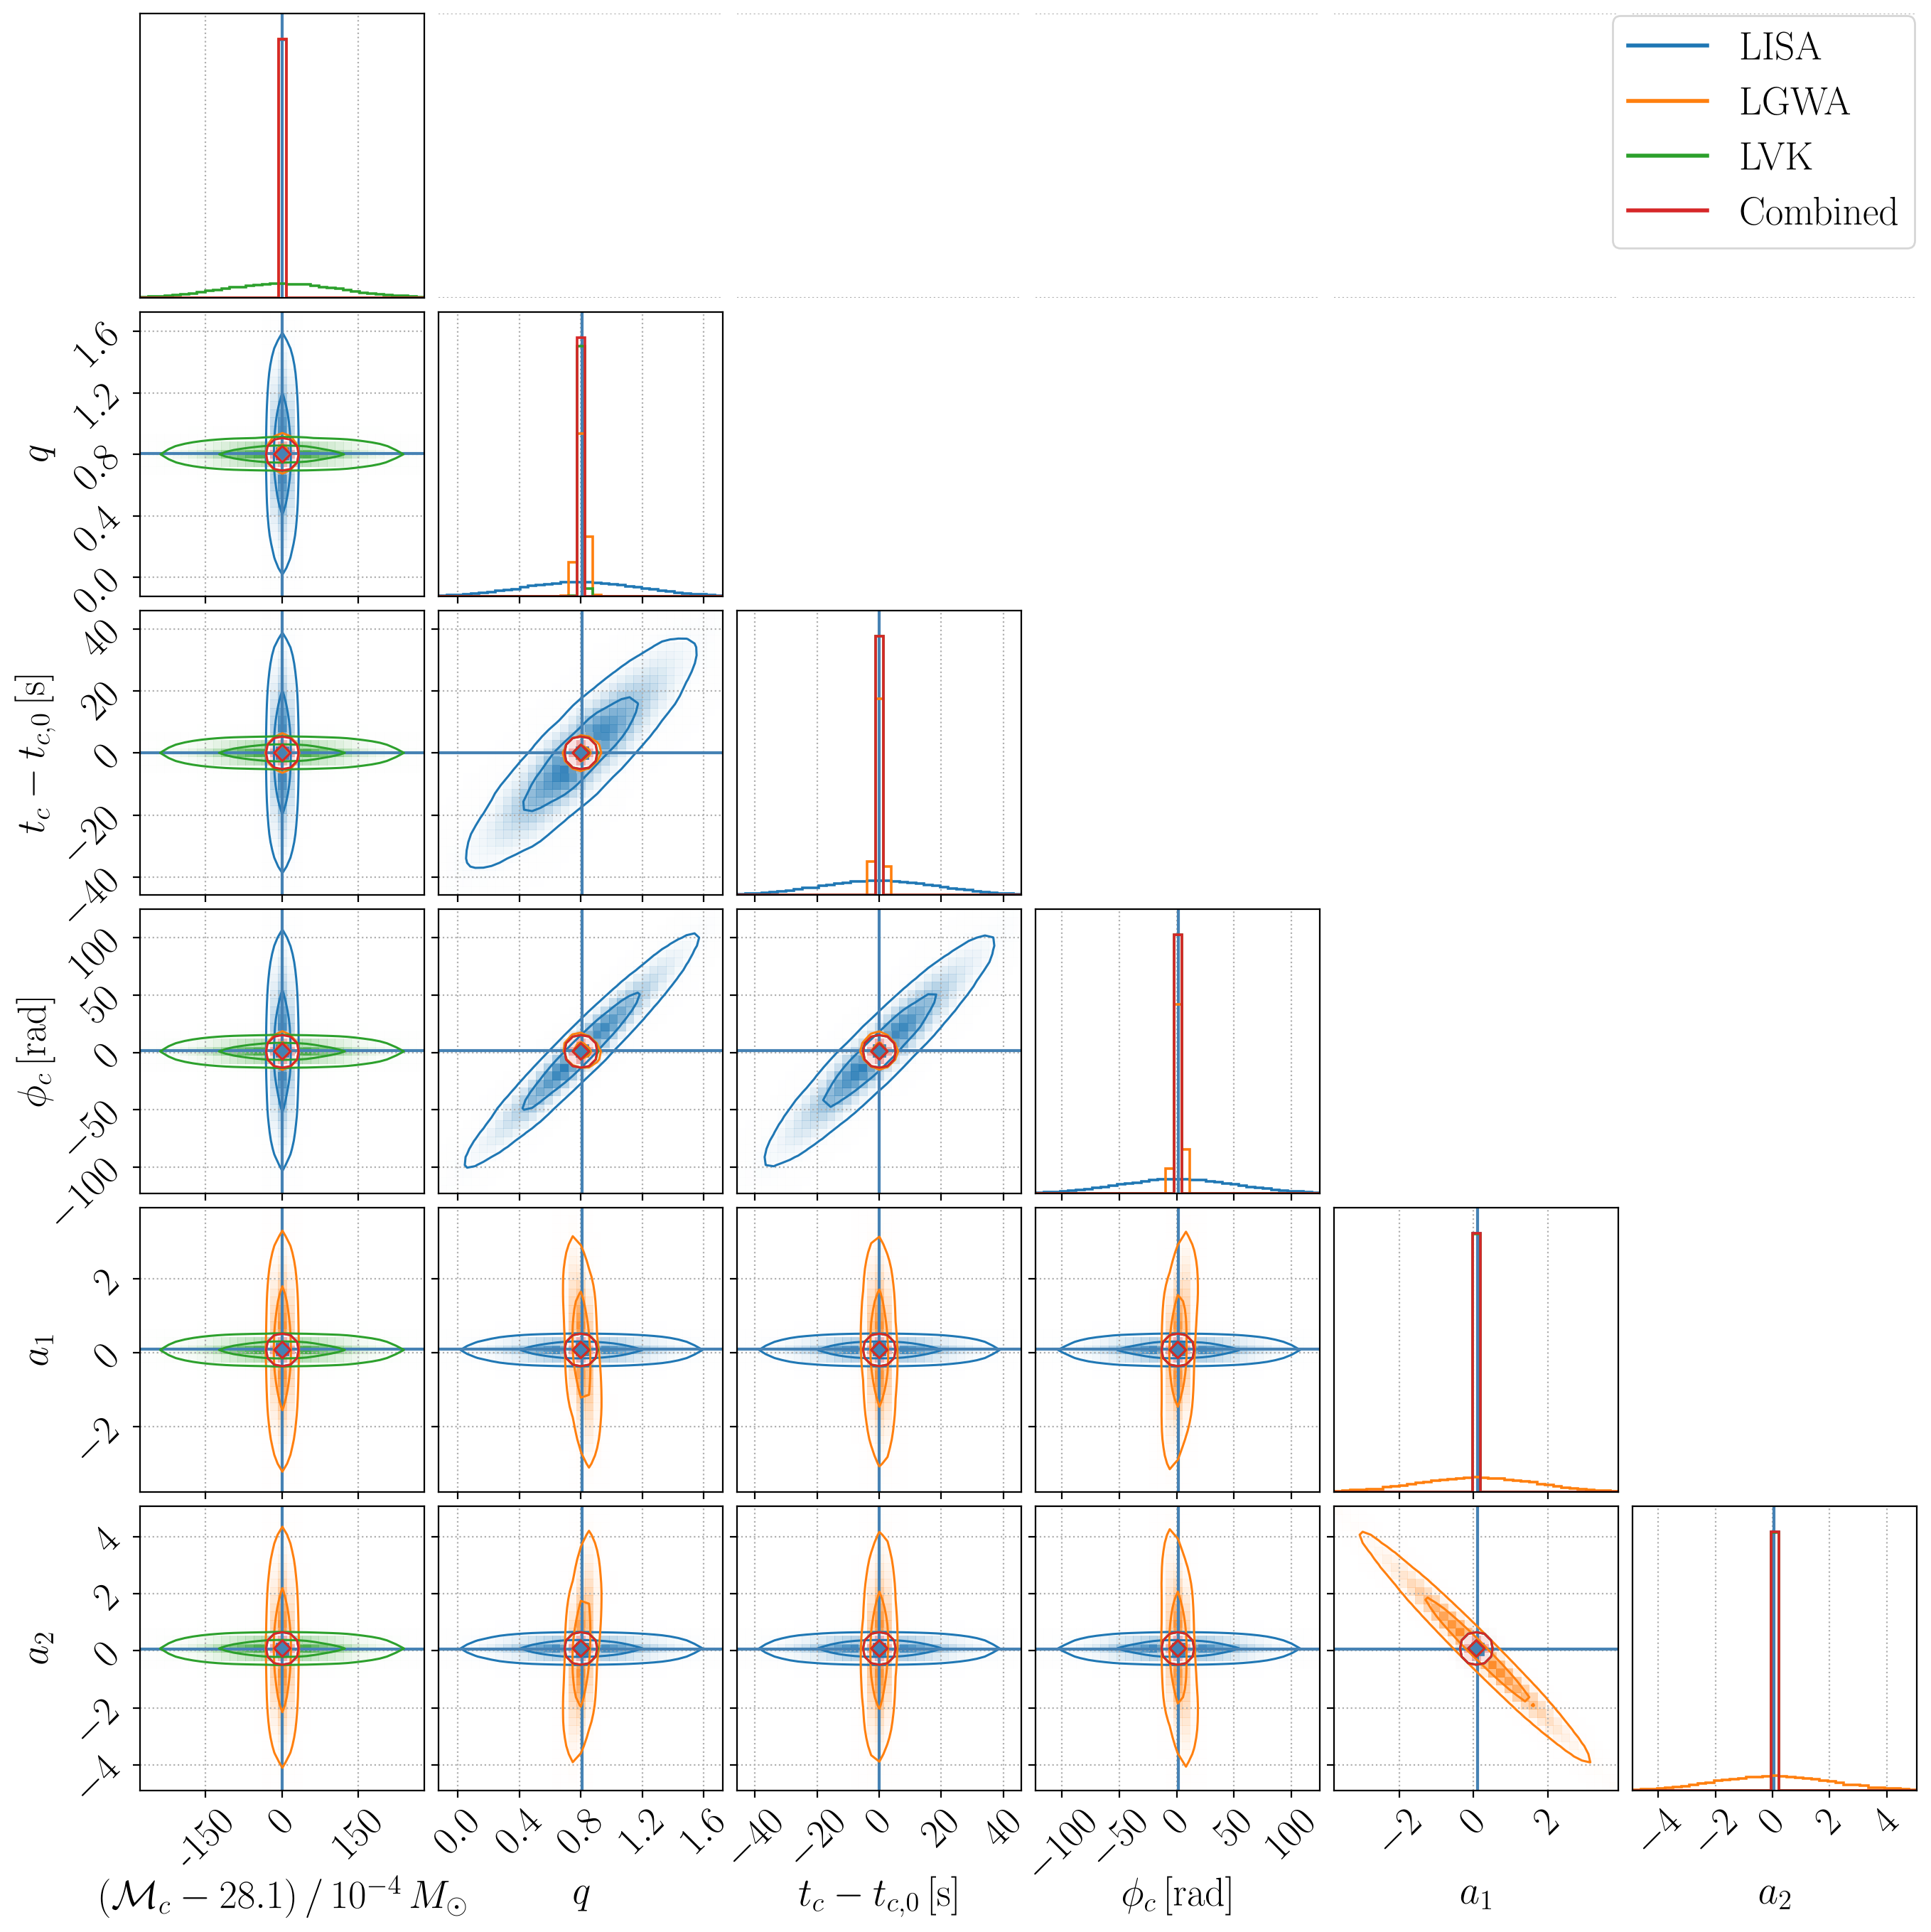

Saved /home/ansonchen/multiband_cosmo/plots/gw150914_gwfish_fisher/gw150914_intrinsic_corner.png


In [8]:
plt.rcParams.update({'font.size': 20})
intrinsic_corner = overlay_corner(
    INTRINSIC_PARAMETERS,
    'GW150914 intrinsic-parameter Fisher constraints',
    'gw150914_intrinsic_corner.png',
    # x_label_y=-0.5,
    hide_first_row_numbers=True,
)

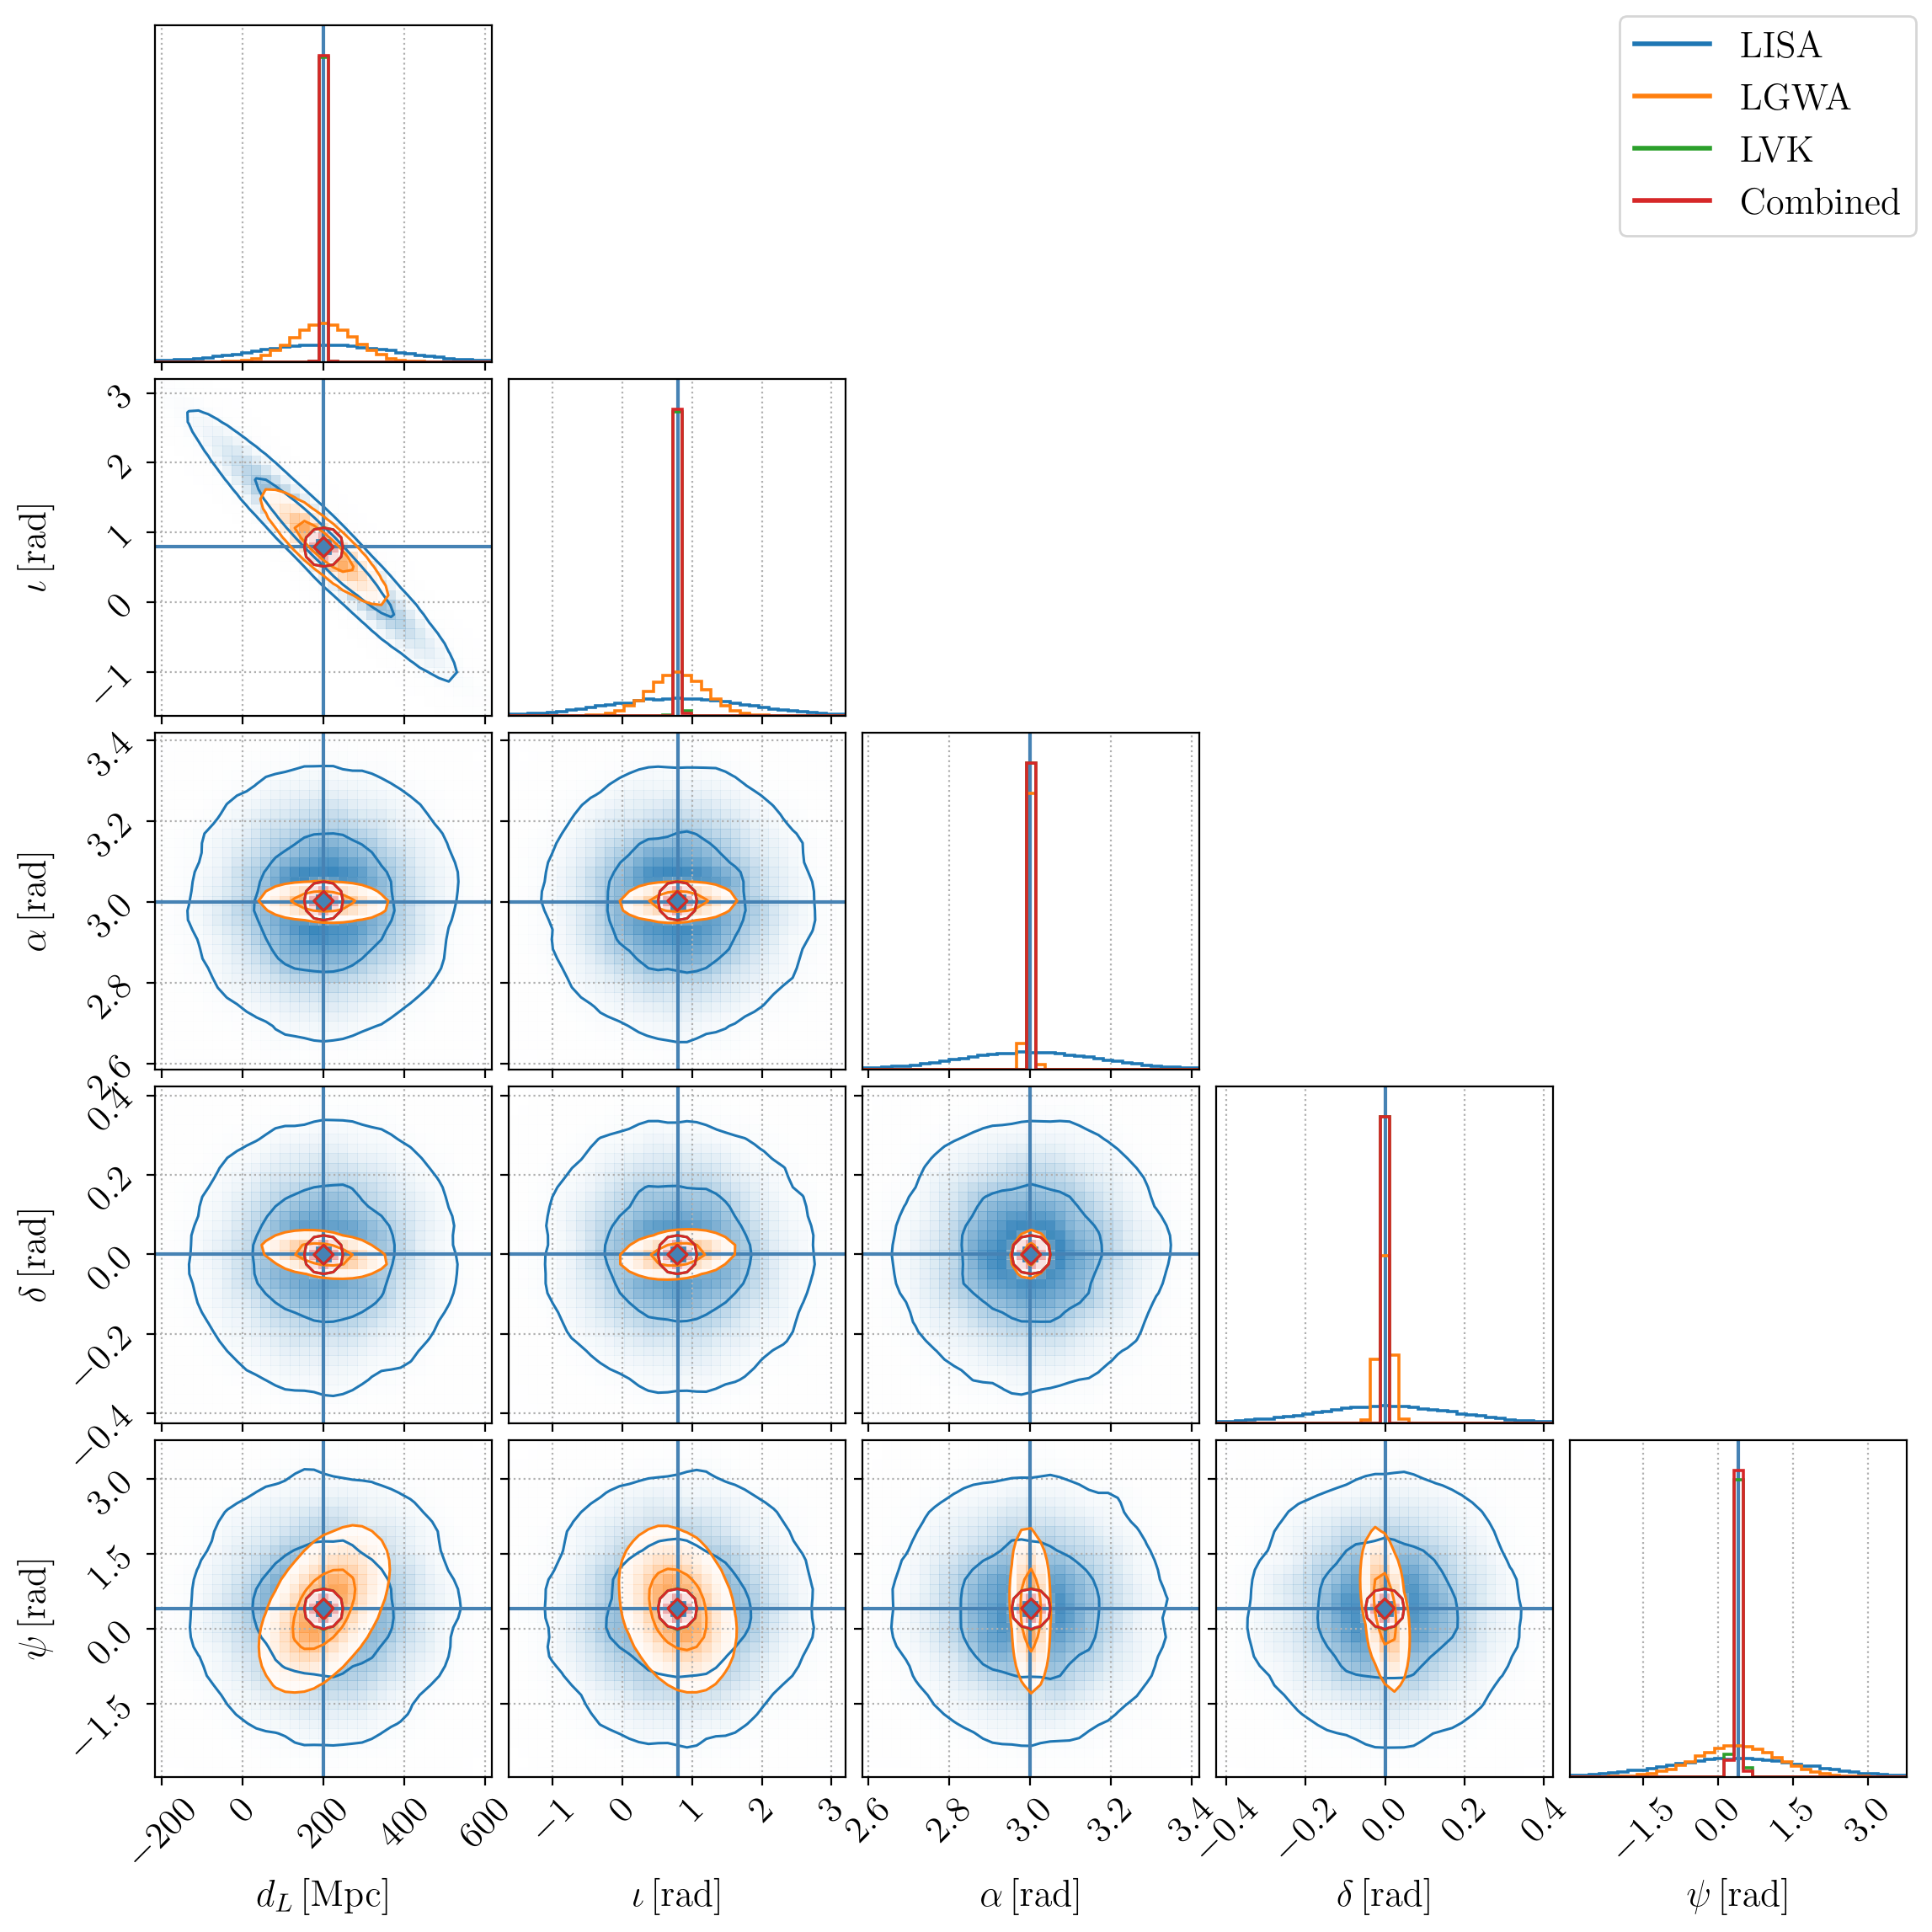

Saved /home/ansonchen/multiband_cosmo/plots/gw150914_gwfish_fisher/gw150914_extrinsic_corner.png


In [9]:
plt.rcParams.update({'font.size': 16})
extrinsic_corner = overlay_corner(
    EXTRINSIC_PARAMETERS,
    'GW150914 extrinsic-parameter Fisher constraints',
    'gw150914_extrinsic_corner.png',
)

## Notes

- Fisher posteriors are local Gaussian approximations and can extend outside
  physical bounds, especially for weak single-detector constraints.
- LISA and LGWA can have nearly singular directions for this full parameter
  set; GWFish's SVD inversion is therefore retained rather than replacing it
  with a direct inverse.
- The two CE instruments use the same CE2 PSD at the LHO and LLO positions
  and orientations. This is a two-site network, not two copies of one response.
- For plotting only, coalescence time and coalescence phase are grouped with
  the intrinsic parameters, as requested.

- The reported 90% sky-localization area uses the covariance-aware Gaussian expression
  $\Delta\Omega_{90}=\pi\chi^2_2(0.9)|\cos\delta|\sqrt{\Sigma_{\alpha\alpha}\Sigma_{\delta\delta}-\Sigma_{\alpha\delta}^2}$, where $\chi^2_2(0.9)=-2\ln(0.1)$, and is quoted in steradians and square degrees.

- The LVK network uses the built-in GWFish `LHO`, `LLO`, `VIR`, and `KAG`
  detector configurations. Their PSD files are the GWFish O5 LIGO/Virgo
  curves and the bundled KAGRA design curve.
- The corner overlays use LISA, LGWA, LVK, and LISA+LGWA+LVK. The 2CE
  calculation remains in the numerical summaries but is not plotted.
